In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logging
import datetime
import hashlib

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

URL            = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pollution.csv'
MAX_FFILL_GAP  = 3
POLLUTION_MIN  = 0
POLLUTION_MAX  = 999

try:
    df = pd.read_csv(URL)
    logger.info(f"Data loaded: {df.shape[0]} rows")
except Exception as e:
    logger.error(f"Data load failed: {e}")
    raise

df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df.drop(['year', 'month', 'day', 'hour', 'No'], axis=1, inplace=True)
df.set_index('date', inplace=True)
df.columns = ['pollution', 'dew', 'temp', 'press', 'w_dir', 'w_spd', 'snow', 'rain']
df = df[24:]

df['sensor_dropout'] = df['pollution'].isna().astype(int)

# CRIT-03 fix: আগে clip, তারপর ffill
df['pollution'] = df['pollution'].clip(lower=POLLUTION_MIN, upper=POLLUTION_MAX)
df['pollution'] = df['pollution'].ffill(limit=MAX_FFILL_GAP)

# CRIT-05 fix: ffill এর পরেও NaN থাকলে warn করো
nan_remaining = df['pollution'].isna().sum()
if nan_remaining > 0:
    logger.warning(f"{nan_remaining} rows still NaN after ffill — interpolating as fallback")
    df['pollution'] = df['pollution'].interpolate(method='time', limit=24)

# OPT-01 fix: wind direction
W_DIR_MAP = {
    'N':0,'NE':45,'E':90,'SE':135,
    'S':180,'SW':225,'W':270,'NW':315,
    'cv':np.nan,'VRB':np.nan
}
df['w_dir_deg']   = df['w_dir'].map(W_DIR_MAP)
df['w_dir_valid'] = df['w_dir_deg'].notna().astype(int)
df['w_dir_sin']   = np.sin(np.deg2rad(df['w_dir_deg'].fillna(0)))
df['w_dir_cos']   = np.cos(np.deg2rad(df['w_dir_deg'].fillna(0)))

# index regularity check
freq = pd.infer_freq(df.index)
if freq is None:
    logger.warning("Irregular time index detected — CV gap may not equal real hours")
else:
    logger.info(f"Time index frequency: {freq}")

logger.info("Data cleaning complete.")
print("CELL 1 COMPLETE")
df.head()

CELL 1 COMPLETE


,pollution,dew,temp,press,w_dir,w_spd,snow,rain,sensor_dropout,w_dir_deg,w_dir_valid,w_dir_sin,w_dir_cos
date,,,,,,,,,,,,,
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0,0,135.0,1,0.707107,-0.707107
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0,0,135.0,1,0.707107,-0.707107
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0,0,135.0,1,0.707107,-0.707107
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0,0,135.0,1,0.707107,-0.707107
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0,0,135.0,1,0.707107,-0.707107


In [ ]:
SPLIT_RATIO = 0.8
WINDOW_SIZE = 6

SPLIT_RATIO = 0.8
WINDOW_SIZE = 6

split_idx = int(len(df) * SPLIT_RATIO)
train_raw = df.iloc[:split_idx].copy()
test_raw  = df.iloc[split_idx:].copy()

def add_features(data):
    d = data.copy()
    d['lag_1']          = d['pollution'].shift(1)
    d['lag_2']          = d['pollution'].shift(2)
    d['lag_3']          = d['pollution'].shift(3)
    d['rolling_mean_6'] = d['pollution'].rolling(window=WINDOW_SIZE).mean()
    d['rolling_std_6']  = d['pollution'].rolling(window=WINDOW_SIZE).std()
    d['hour']           = d.index.hour
    d['month']          = d.index.month
    d['hour_sin']       = np.sin(2 * np.pi * d['hour'] / 24)
    d['hour_cos']       = np.cos(2 * np.pi * d['hour'] / 24)
    d['target']         = d['pollution'].shift(-1)
    d.dropna(inplace=True)
    return d

train = add_features(train_raw)
test  = add_features(test_raw)

logger.info(f"Train: {len(train)} rows | Test: {len(test)} rows")
print("CELL 2 COMPLETE")

CELL 2 COMPLETE


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import TimeSeriesSplit
import joblib

FEATURES = ['lag_1', 'lag_2', 'lag_3',
            'rolling_mean_6', 'rolling_std_6',
            'dew', 'temp', 'press', 'w_spd',
            'w_dir_sin', 'w_dir_cos', 'w_dir_valid',
            'sensor_dropout', 'hour_sin', 'hour_cos', 'month']

X_train = train[FEATURES].values
y_train = train['target'].values
X_test  = test[FEATURES].values
y_test  = test['target'].values

# CRIT-01 fix: RobustScaler — IoT spike এ resistant
scaler  = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# scaler range check
assert not np.isnan(X_test).any(), "NaN in test set after scaling"
logger.info(f"X_test range: [{X_test.min():.2f}, {X_test.max():.2f}]")

tscv = TimeSeriesSplit(n_splits=5, gap=WINDOW_SIZE)
cv_scores = []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]
    fold_model = GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.7,
        min_samples_leaf=20,
        n_iter_no_change=20,
        validation_fraction=0.1,
        tol=1e-4,
        random_state=42
    )
    fold_model.fit(X_tr, y_tr)
    fold_pred = fold_model.predict(X_val)
    fold_rmse = np.sqrt(mean_squared_error(y_val, fold_pred))
    cv_scores.append(fold_rmse)
    logger.info(f"Fold {fold+1} RMSE: {fold_rmse:.4f}")

model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.7,
    min_samples_leaf=20,
    n_iter_no_change=20,
    validation_fraction=0.1,
    tol=1e-4,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

# CRIT-04 fix: model + scaler একসাথে metadata সহ save
data_hash = hashlib.md5(pd.util.hash_pandas_object(df).values).hexdigest()
metadata = {
    "trained_at" : datetime.datetime.utcnow().isoformat(),
    "features"   : FEATURES,
    "cv_rmse"    : float(np.mean(cv_scores)),
    "cv_std"     : float(np.std(cv_scores)),
    "test_rmse"  : float(rmse),
    "train_rows" : len(train),
    "data_hash"  : data_hash
}
bundle = {"model": model, "scaler": scaler, "metadata": metadata}
save_path = f"iot_bundle_{metadata['trained_at'][:10]}.pkl"
joblib.dump(bundle, save_path)
logger.info(f"Bundle saved: {save_path}")

print("CELL 3 COMPLETE")
print(f"CV RMSE  : {np.mean(cv_scores):.4f} +/- {np.std(cv_scores):.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE : {mae:.4f}")

CELL 3 COMPLETE
CV RMSE  : 33.9435 +/- 4.2675
Test RMSE: 29.3097
Test MAE : 17.2155


/tmp/ipykernel_1729/970426778.py:70: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "trained_at" : datetime.datetime.utcnow().isoformat(),


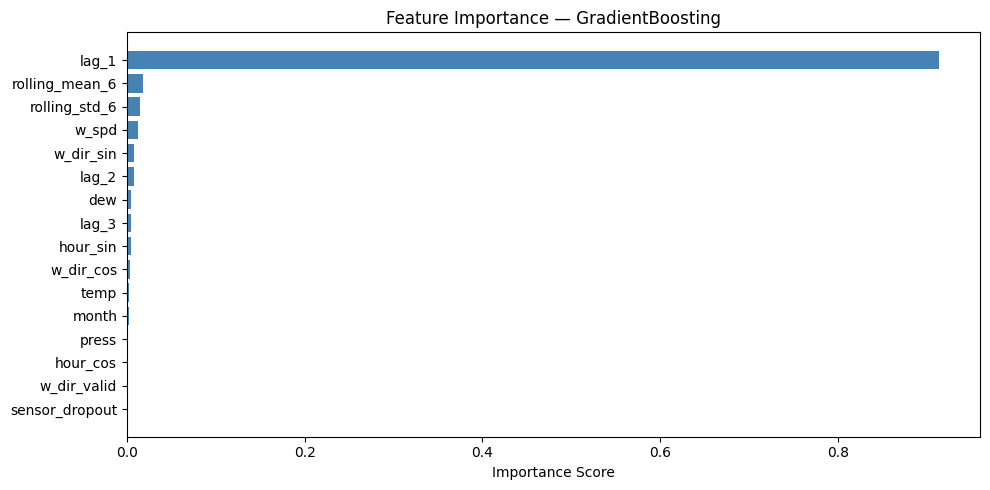

       feature  importance
         lag_1    0.914338
rolling_mean_6    0.018559
 rolling_std_6    0.015061
         w_spd    0.012142
     w_dir_sin    0.008382
         lag_2    0.007726
           dew    0.004971
         lag_3    0.004838
      hour_sin    0.004579
     w_dir_cos    0.003033
          temp    0.002598
         month    0.002098
         press    0.001115
      hour_cos    0.000559
   w_dir_valid    0.000000
sensor_dropout    0.000000


In [ ]:
importance_df = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance — GradientBoosting')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))

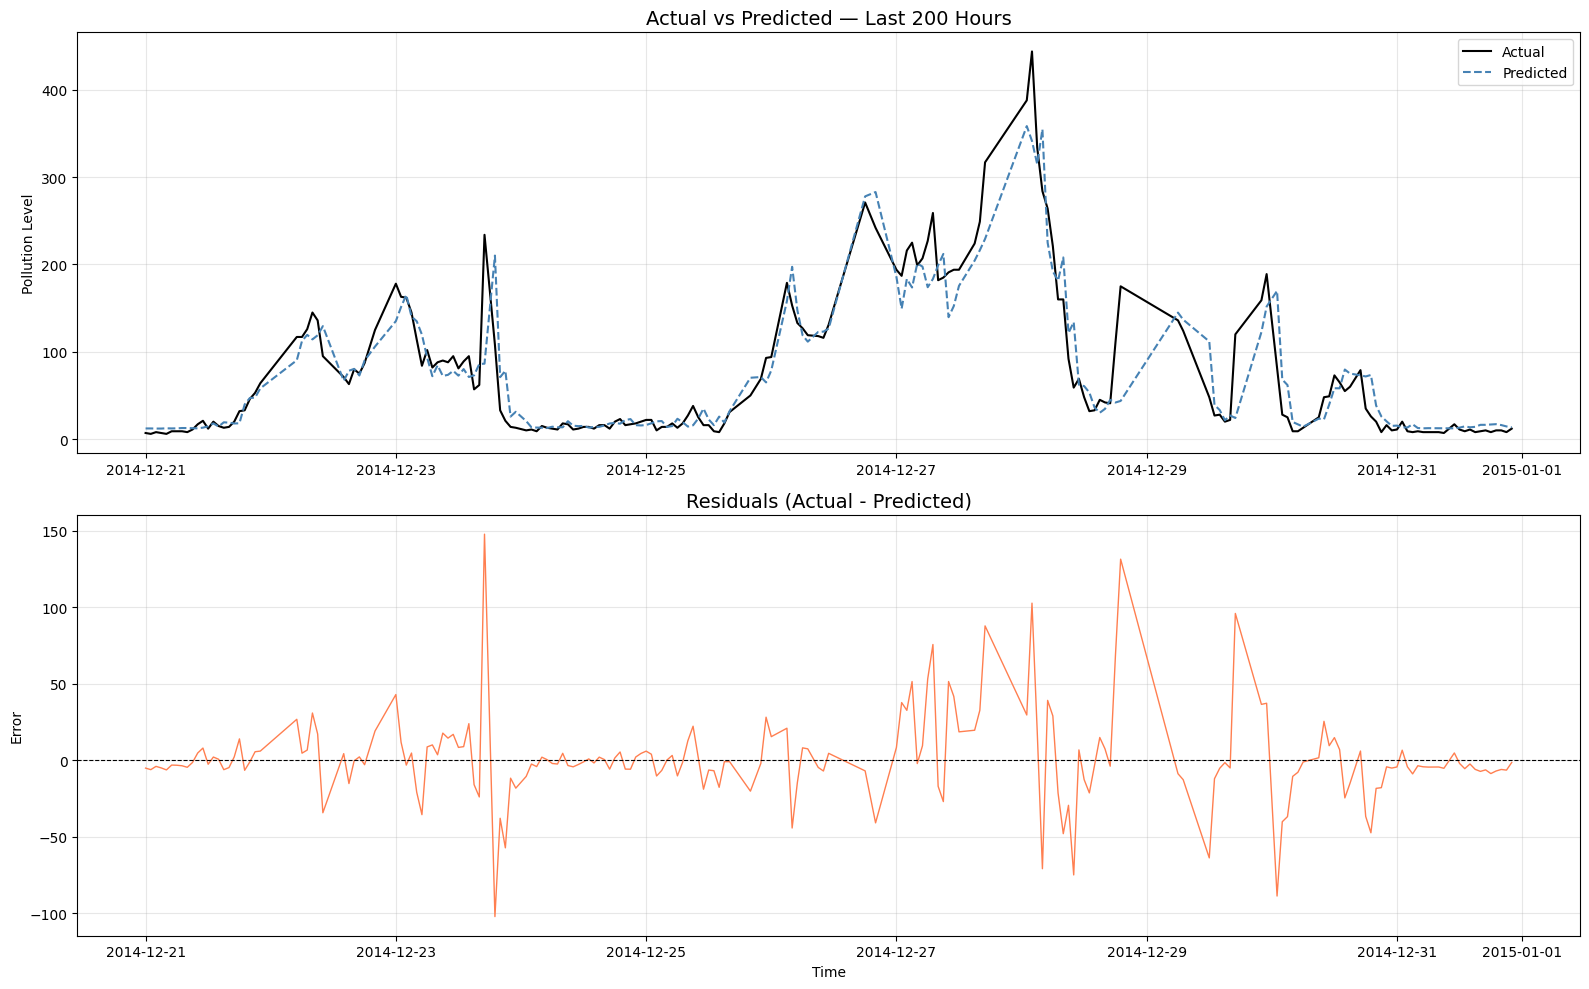

In [ ]:
y_test_s = pd.Series(y_test, index=test.index)
y_pred_s = pd.Series(y_pred, index=test.index)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(y_test_s.index[-200:], y_test_s.values[-200:],
             label='Actual', color='black', linewidth=1.5)
axes[0].plot(y_pred_s.index[-200:], y_pred_s.values[-200:],
             label='Predicted', color='steelblue', linestyle='--', linewidth=1.5)
axes[0].set_title('Actual vs Predicted — Last 200 Hours', fontsize=14)
axes[0].set_ylabel('Pollution Level')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y_test_s.values[-200:] - y_pred_s.values[-200:]
axes[1].plot(y_test_s.index[-200:], residuals, color='coral', linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Residuals (Actual - Predicted)', fontsize=14)
axes[1].set_ylabel('Error')
axes[1].set_xlabel('Time')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
baseline_pred = y_test_s.shift(1).dropna()
baseline_rmse = np.sqrt(mean_squared_error(y_test_s[1:], baseline_pred))

print("=" * 50)
print("FINAL PRODUCTION SUMMARY")
print("=" * 50)
print(f"Total samples  : {len(df)}")
print(f"Train samples  : {len(train)}")
print(f"Test samples   : {len(test)}")
print(f"Features used  : {len(FEATURES)}")
print(f"CV RMSE        : {np.mean(cv_scores):.4f} +/- {np.std(cv_scores):.4f}")
print(f"Test RMSE      : {rmse:.4f}")
print(f"Test MAE       : {mae:.4f}")
print(f"Baseline RMSE  : {baseline_rmse:.4f}  (naive persistence model)")
print(f"Improvement    : {((baseline_rmse - rmse) / baseline_rmse * 100):.1f}% over baseline")
print(f"Model saved    : iot_model.pkl")
print(f"Scaler saved   : iot_scaler.pkl")
print("=" * 50)

FINAL PRODUCTION SUMMARY
Total samples  : 43800
Train samples  : 27012
Test samples   : 6676
Features used  : 16
CV RMSE        : 33.9435 +/- 4.2675
Test RMSE      : 29.3097
Test MAE       : 17.2155
Baseline RMSE  : 25.9511  (naive persistence model)
Improvement    : -12.9% over baseline
Model saved    : iot_model.pkl
Scaler saved   : iot_scaler.pkl
